# 04 - Integration, Weather, Labeling, Validation

Merge feature vectors with schedule labels, enrich weather/airport/congestion features, generate labels, and validate the final ML table.

## 1. Setup

In [1]:
from pathlib import Path
import sys, json, subprocess
import pandas as pd
from IPython.display import display, Image, HTML


def resolve_project_root() -> Path:
    candidates = [Path.cwd().resolve(), Path.cwd().resolve().parent, Path('..').resolve()]
    for candidate in candidates:
        if (candidate / 'src').exists() and (candidate / 'configs' / 'config.yaml').exists():
            return candidate
    raise FileNotFoundError('Could not resolve project root. Run this notebook from the repo or notebooks folder.')

PROJECT_ROOT = resolve_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils import load_config
from src.pipeline_reporting import configure_pretty_logging, output_dir, save_dataset_inventory, save_dataframe, save_table_image, save_bar_chart

config = load_config(PROJECT_ROOT / 'configs' / 'config.yaml')
paths = config['paths']
processed_dir = PROJECT_ROOT / paths.get('processed_data_dir', 'data/processed')
raw_dir = PROJECT_ROOT / paths.get('raw_data_dir', 'data/raw')
outputs_dir = PROJECT_ROOT / 'outputs'
notebook_out = output_dir('04_dataset_integration', root=outputs_dir / 'notebook_reports')
log_file = configure_pretty_logging(PROJECT_ROOT / 'logs', '04_dataset_integration')
print('Project root:', PROJECT_ROOT)
print('Notebook output dir:', notebook_out)
print('Notebook log file:', log_file)

Project root: C:\Code\flight-disruption-prediction
Notebook output dir: C:\Code\flight-disruption-prediction\outputs\notebook_reports\04_dataset_integration
Notebook log file: C:\Code\flight-disruption-prediction\logs\04_dataset_integration_20260420_173436.log


## 2. Controls

In [2]:
RUN_MERGE = False
RUN_WEATHER = False
RUN_LABEL = False
RUN_VALIDATE = False
FORCE = True
print({k:v for k,v in {'RUN_MERGE':RUN_MERGE,'RUN_WEATHER':RUN_WEATHER,'RUN_LABEL':RUN_LABEL,'RUN_VALIDATE':RUN_VALIDATE}.items()})

{'RUN_MERGE': False, 'RUN_WEATHER': False, 'RUN_LABEL': False, 'RUN_VALIDATE': False}


## 3. Optional Stage Execution

In [3]:
import main as pipeline_main
from src.data_validator import DataValidator
validator = DataValidator(mode=config.get('validation_mode', 'warn_only'), log_dir=PROJECT_ROOT / 'logs')
if RUN_MERGE:
    pipeline_main.stage_merge(config, validator, force=FORCE)
if RUN_WEATHER:
    pipeline_main.stage_weather(config, validator, force=FORCE)
if RUN_LABEL:
    pipeline_main.stage_label(config, validator, force=FORCE)
if RUN_VALIDATE:
    pipeline_main.stage_validate(config, force=FORCE)
if not any([RUN_MERGE, RUN_WEATHER, RUN_LABEL, RUN_VALIDATE]):
    print('No stages executed. Toggle controls above to rebuild.')

No stages executed. Toggle controls above to rebuild.


## 4. Integration Outputs

,dataset,path,exists,size_mb,rows,columns,min_time,max_time
0,features,C:\Code\flight-disruption-prediction\data\proc...,True,11.87,84916,47,2022-05-02 00:00:00+00:00,2022-05-30 23:58:10+00:00
1,merged,C:\Code\flight-disruption-prediction\data\proc...,True,18.05,83601,96,2022-05-01 16:00:00+00:00,2022-05-31 00:52:00+00:00
2,weather,C:\Code\flight-disruption-prediction\data\proc...,True,18.39,83601,120,2022-05-01 16:00:00+00:00,2022-05-31 00:52:00+00:00
3,labeled,C:\Code\flight-disruption-prediction\data\proc...,True,10.32,83601,61,2022-05-01 16:00:00+00:00,2022-05-31 00:52:00+00:00
4,final_ml,C:\Code\flight-disruption-prediction\data\proc...,True,10.37,83601,70,2022-05-01 16:00:00+00:00,2022-05-31 00:52:00+00:00


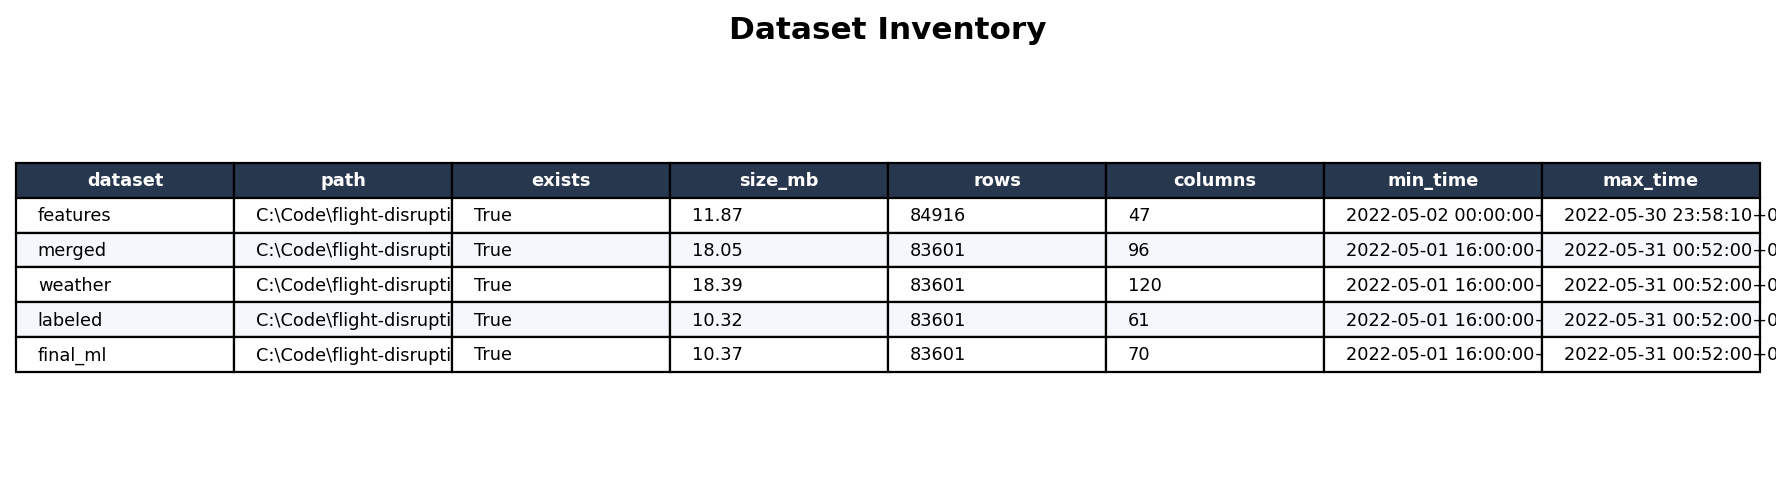

In [4]:
inventory = save_dataset_inventory({
    'features': processed_dir / paths.get('features_file', 'trajectory_features.parquet'),
    'merged': processed_dir / 'ml_dataset_merged.parquet',
    'weather': processed_dir / 'ml_dataset_weather.parquet',
    'labeled': processed_dir / 'ml_dataset_labeled.parquet',
    'final_ml': processed_dir / paths.get('ml_dataset_file', 'ml_dataset.parquet'),
}, notebook_out)
display(inventory)
display(Image(filename=str(notebook_out / 'dataset_inventory.png')))

## 5. Final Dataset Visual Checks

Final ML shape: (83601, 70)


,flight_key,region,source_dataset,scheduled_dep,scheduled_arr,origin,destination,cancelled,flight_duration,trajectory_length,...,weather_severity_dest,match_quality,label_source,match_score_minutes,match_anchor,match_confidence,training_eligible,feature_quality_score,delay_minutes,label
0,B633_20220501,US,bts,2022-05-01 16:00:00+00:00,2022-05-01 22:43:00+00:00,KBOS,KSFO,0,1660.0,0.000000,...,NaN,multi_anchor_service_day<180m,bts_verified,112.666667,arrival,0.121622,True,0.822222,6.0,Normal
1,AS714_20220501,US,bts,2022-05-01 16:33:00+00:00,2022-05-01 22:00:00+00:00,KSEA,KEWR,0,3580.0,844.654592,...,0.0,multi_anchor_service_day<180m,bts_verified,179.833333,arrival,0.087561,True,1.000000,0.0,Normal
2,UA1540_20220501,US,bts,2022-05-01 16:35:00+00:00,2022-05-01 22:05:00+00:00,KSFO,KRSW,0,290.0,48.380599,...,NaN,multi_anchor_service_day<180m,bts_verified,120.000000,arrival,0.116667,True,0.755556,22.0,Late
3,WN1726_20220501,US,bts,2022-05-01 17:30:00+00:00,2022-05-01 22:40:00+00:00,KBWI,KLAS,0,3010.0,484.836821,...,2.0,multi_anchor_service_day<180m,bts_verified,172.000000,arrival,0.258621,True,0.888889,50.0,Late
4,UA1172_20220501,US,bts,2022-05-01 17:40:00+00:00,2022-05-02 00:22:00+00:00,KBOS,KSFO,0,240.0,17.937088,...,NaN,multi_anchor_service_day<180m,bts_verified,17.833333,arrival,0.269807,True,0.888889,-1.0,Normal


,label,count
0,Normal,65623
1,Late,17901
2,Cancelled,77


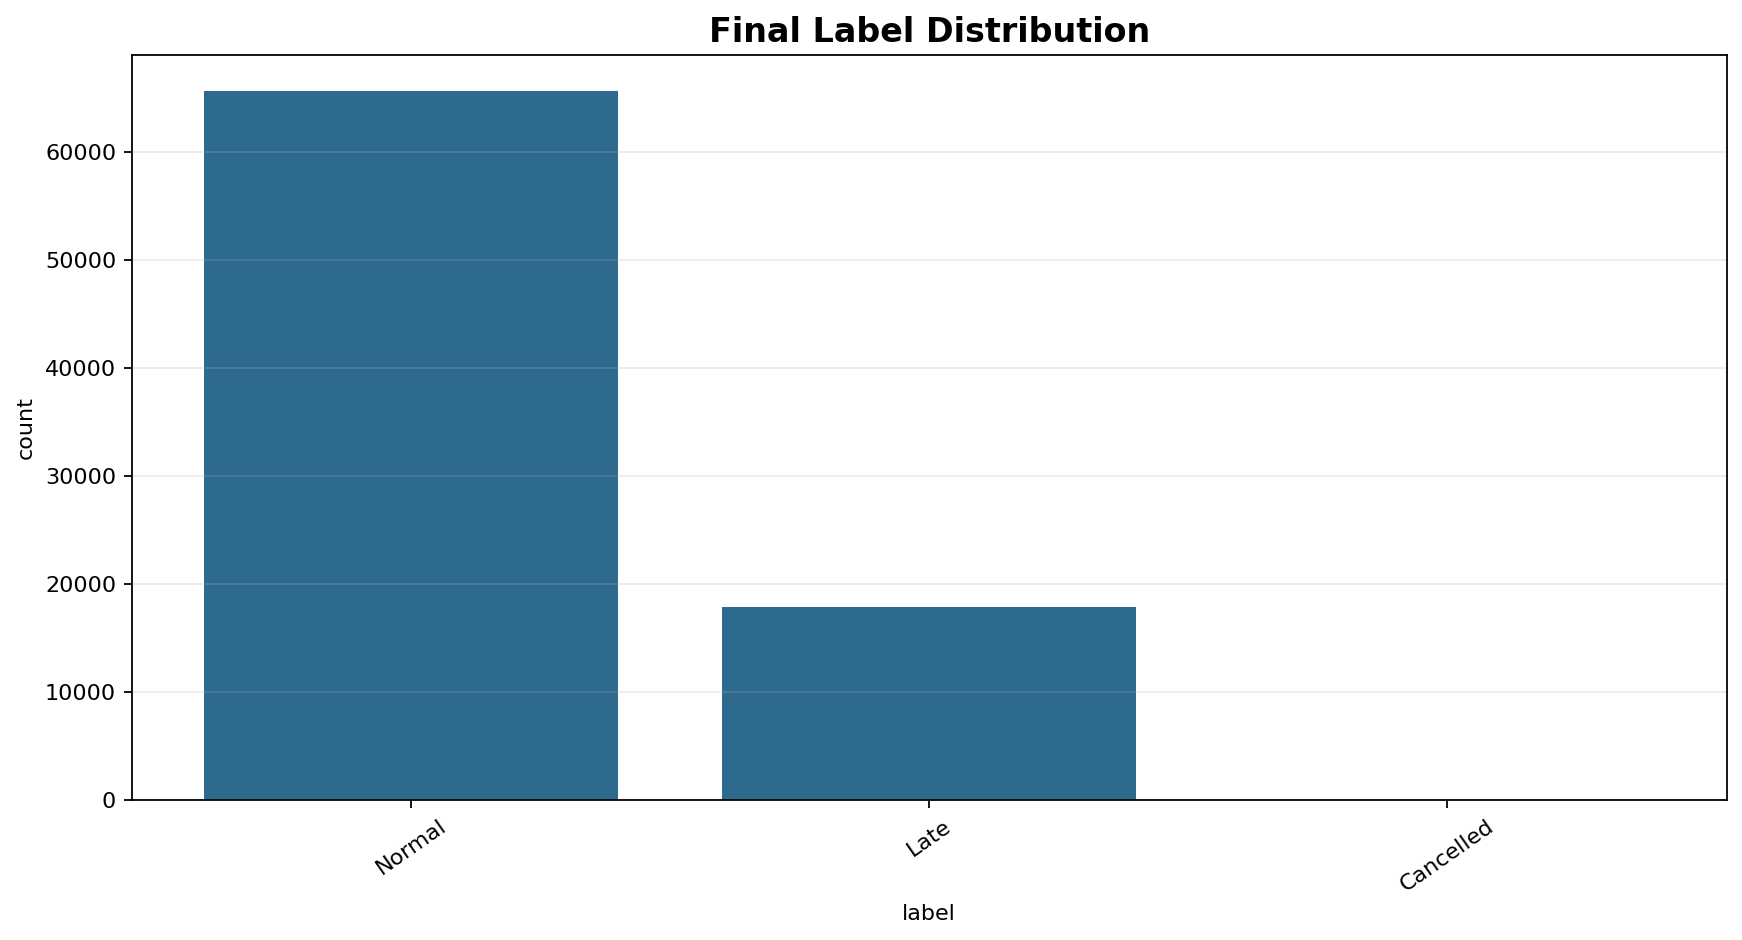

In [5]:
final_path = processed_dir / paths.get('ml_dataset_file', 'ml_dataset.parquet')
if final_path.exists():
    df_ml = pd.read_parquet(final_path)
    print('Final ML shape:', df_ml.shape)
    display(df_ml.head())
    if 'label' in df_ml.columns:
        labels = df_ml['label'].value_counts(dropna=False).rename_axis('label').reset_index(name='count')
        save_dataframe(labels, 'final_label_distribution', notebook_out)
        save_bar_chart(labels, 'label', 'count', 'final_label_distribution', notebook_out, title='Final Label Distribution')
        display(labels)
        display(Image(filename=str(notebook_out / 'final_label_distribution.png')))
else:
    print('Final ML dataset missing.')